# Modeling Intro: From Script to Library

In Notebook 01, you improved working code by making small, high-value changes.
In this notebook, you continue that same process by moving those functions into a reusable Python library.

The goal is still the same: keep behavior working while improving portability, reuse, and communication.

## Why This Matters

In scientific work, "good enough to run" is often the right starting point.
Software engineering adds lightweight improvements so the same code is easier to maintain, reuse, and share.

By the end of this notebook, you should be able to:

- Move working functions from a notebook into a Python module
- Import and run those functions from a notebook
- Use discovery tools such as `dir()` and `help()`
- Explain why this structure supports safe, portable, reproducible, robust, and literate software

## Exercise 1: Generate a Python Library

Copy the functions you built in Notebook 01 into a new Python file with a `.py` extension in this same folder.
Use a clear filename such as `barycentric_triangle.py`.

Then run the next two code cells.
They will not work until your module and function names match the imports and calls below.

Your immediate goal is to import the module, generate a triangle, and plot a point.

In [1]:
%load_ext autoreload
%autoreload 2

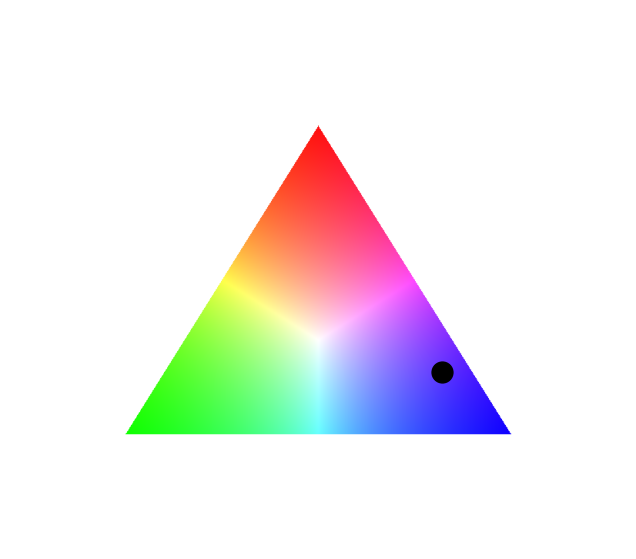

In [2]:
import barycentric_triangle as bt

bt.generate_triangle()
bt.display_triangle()

### Important Note: Developing Libraries in Jupyter

When Python successfully imports a module, it stores that module in memory. If you later edit the source file and run the import statement again, Python will usually **reuse the already-loaded version** rather than reading the file again. This can be confusing when developing your own libraries because your changes may not appear to take effect, even though you saved the file.

One solution is to restart the Jupyter kernel every time you modify the library. While this works, it quickly becomes tedious during development.

Fortunately, Jupyter provides a convenient solution. Add the following magic commands near the top of your notebook:

```python
%load_ext autoreload
%autoreload 2
```

With these enabled, Python will automatically reload imported modules whenever their source files change. This makes library development inside Jupyter notebooks much smoother.

Automatic reloading is useful during active development. In production workflows, use it more selectively.

### Team/Class Reflection

- What did you name your module file, and why?
- Which function names needed to be synchronized between Notebook 01 and your library?
- What import or naming issue took the longest to debug?
- How does moving code to a `.py` file improve reuse for your team?

#my initial confusion came from the disorganization of my .py code, as I was thrown off by how the "plot point" was defined as its own function, but added to the plot within display_triangle(). Since resolved. I also typically prefer to keep function names as whole-words rather than abbreviations or acronyms. This helps me interpret wholistic code since my functions won't blend in too much with the rest of the generic programming jargon and junk.

## Exercise 2: Increasing Portability

In Step 1, your code became importable.
Now focus on portability for other users: can someone discover what your library contains and how to use it without asking you?

Python provides built-in tools for this:

- `dir(module)` to see available names
- `help(function)` to inspect purpose, inputs, defaults, and expected behavior

Run the next cells and adapt naming as needed so they work with your library.

In [3]:
import barycentric_triangle

dir(barycentric_triangle)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'display_triangle',
 'generate_triangle',
 'np',
 'plot_point',
 'plt',
 'point_in_triangle']

The `dir()` function lists names currently available in a module.
This is often the first step when exploring unfamiliar code.

Once you find an interesting function, use `help()` to inspect documentation and expected usage.

In [6]:
help(barycentric_triangle.__doc__)

Help on NoneType object:

class NoneType(object)
 |  Methods defined here:
 |
 |  __bool__(self, /)
 |      True if self else False
 |
 |  __eq__(self, value, /)
 |      Return self==value.
 |
 |  __ge__(self, value, /)
 |      Return self>=value.
 |
 |  __gt__(self, value, /)
 |      Return self>value.
 |
 |  __hash__(self, /)
 |      Return hash(self).
 |
 |  __le__(self, value, /)
 |      Return self<=value.
 |
 |  __lt__(self, value, /)
 |      Return self<value.
 |
 |  __ne__(self, value, /)
 |      Return self!=value.
 |
 |  __repr__(self, /)
 |      Return repr(self).
 |
 |  ----------------------------------------------------------------------
 |  Static methods defined here:
 |
 |  __new__(*args, **kwargs)
 |      Create and return a new object.  See help(type) for accurate signature.



The `help()` function displays documentation, including purpose, inputs, and expected behavior.
Clear docstrings make software more literate and easier for teammates to adopt.

Get the following help call working with your function and module names.

In [7]:
help(barycentric_triangle.plot_point)

Help on function plot_point in module barycentric_triangle:

plot_point(red, green, blue)
    # Exercise 3: Add Project Point



At this point, you have transformed a one-off script into a reusable Python library.
This reflects a common research software path:

Experiment -> Working Script -> Reusable Functions -> Library -> Documented Tool

As you continue improving your library, remember that future users may not have your notebook, your comments, or your memory of how the code evolved.
Names, defaults, and docstrings are part of the software interface.

### Team/Class Reflection

- What did `dir()` reveal that a new user would care about?
- What did `help()` reveal that was missing or unclear?
- Which naming or docstring change most improved discoverability?
- What is one small edit that would make this library easier for a classmate to use?

I like how this tool will help me piece together each function component, as the "linearity" of programming is often where I find most of my errors.

The next step extends this same library into a simple command-line interface so it can be used outside notebooks as well.

## Exercise 3: Turning Your Library into a Command Line Tool

So far, we have used our library from inside a Jupyter notebook.

This is a common workflow during development and exploration. However, many research software tools are eventually used outside of notebooks. One common approach is to provide a command-line interface (CLI) that allows users to run the software directly from a terminal.

In this step, you will extend your library so it can be used both:

* as a Python module imported into notebooks, and
* as a standalone command-line program.

This introduces an important Python pattern:

```python
if __name__ == "__main__":
```

This statement allows a file to behave differently depending on how it is used.

When a file is imported:

```python
from barycentric_triangle import generate_triangle
```

Python loads the functions but does not execute the code inside the if ```__name__ == "__main__"``` block.

However, when the file is run from the command line:

```bash
python barycentric_triangle.py
```

Python executes the code inside the block.

This allows one file to serve as both a reusable library and a command-line tool.

### Your Goal

Extend your library so it can:

* Generate a barycentric triangle.
* Plot one or more points.
* Save the resulting figure to a file.
* Be run directly from the command line.

For example:
```bash
python barycentric_triangle.py
```
might generate a default triangle image and a more advanced version might support arguments such as:
```bash
python barycentric_triangle.py output.png 
```
or
```bash
python barycentric_triangle.py output.png 0.5 0.3 0.2
```

### Test Your Program

Run these command-line options from the repository folder. You can also run them from a notebook cell using the `!` prefix.

In [1]:
!python barycentric_triangle.py output.png 

Figure(800x700)


In [2]:
!python barycentric_triangle.py output.png 0.5 0.3 0.2

Figure(800x700)


### Team/Class Reflection

- What advantages does a command-line interface provide?
- How does a command-line tool differ from a notebook workflow?
- Why might a researcher want both options?
- What code belongs inside `if __name__ == "__main__":`?
- What code should remain in reusable functions?